### k-means Clustering using scikit-learn

Although k-means clustering can be applied to data in higher dimensions, we will walk through the following examples using a simple two-dimensional dataset for the purpose of visualization:

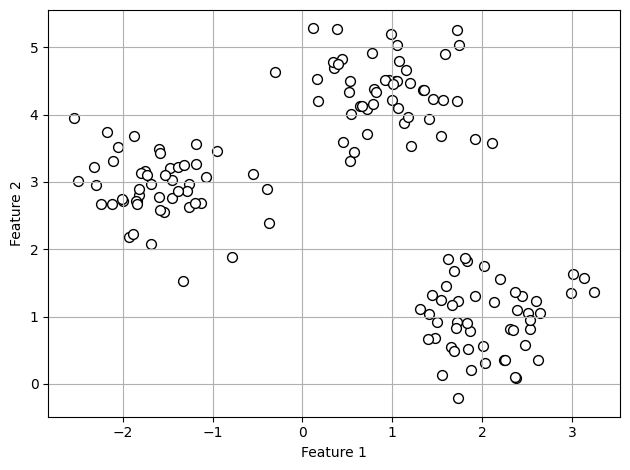

In [1]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=150, 
                  centers=3, 
                  n_features=2, 
                  cluster_std=0.5,
                  shuffle=True,
                  random_state=0)

import matplotlib.pyplot as plt

plt.scatter(X[:, 0],
            X[:, 1],
            c='white',
            marker='o',
            edgecolor='black',
            s=50)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid()
plt.tight_layout()
plt.show()

The dataset that we created consists of 150 randomly generated points that are roughly grouped into three regions with higher density, which is visualized via a two-dimensional scatterplot.

Let's apply k-means to our example using the KMeans class from scikit-learn's cluster module:

In [2]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3,
            init='random',
            n_init=10,
            max_iter=300,
            tol=1e-04,
            random_state=0)
y_km = km.fit_predict(X)

Using the preceding code, we set the number of desired clusters to 3, having to specify the number of clusters a priori is one of the limitations of k-means. We set n_init = 10 to run the k-means clustering algorithms 10 times independently, with different random centroids to choose the final model as the one with the lowest SSE. Via the max_iter parameter, we specify the maximum number of iterations for each single run (here, 300). Note that the k-means implementation in scikit-learn stops early if it converges before the maximum number of iterations is reached. However, it is possible that k-means does not reach convergence for a particular run, which can be problematic (computationally expensive) if we choose relatively large values for max_iter. One way to deal with convergence problems is to choose larger values for tol, which is a parameter that controls the tolerance with regard to the changes in the within-cluster SSE to declare convergence. 

Having predicted the cluster labels, y_km, and discussed some of the challenges of the k-means algorithm, let's now visualize the clusters that k-means identified in the dataset together with the cluster centroids. These are stored under the cluster_centers_ attribute of the fitted KMeans object:

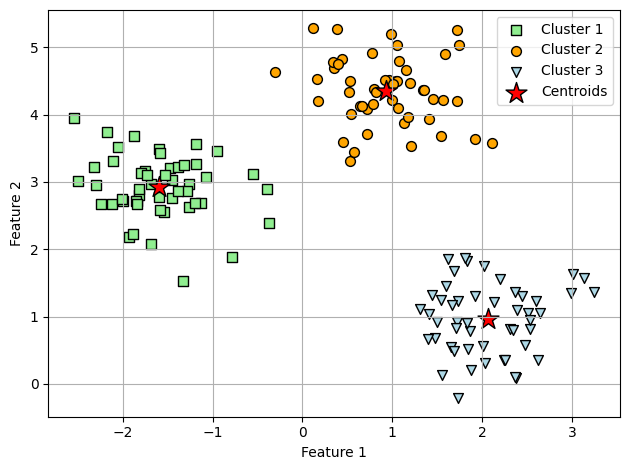

In [3]:
plt.scatter(X[y_km == 0, 0],
            X[y_km == 0, 1],
            s=50, c='lightgreen',
            marker='s', edgecolor='black',
            label='Cluster 1')
plt.scatter(X[y_km == 1, 0],
            X[y_km == 1, 1],
            s=50, c='orange',
            marker='o', edgecolor='black',
            label='Cluster 2')
plt.scatter(X[y_km == 2, 0],
            X[y_km == 2, 1],
            s=50, c='lightblue',
            marker='v', edgecolor='black',
            label='Cluster 3')
plt.scatter(km.cluster_centers_[:, 0],
            km.cluster_centers_[:, 1],
            s=250, marker='*',
            c='red', edgecolor='black',
            label='Centroids')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(scatterpoints=1)
plt.grid()
plt.tight_layout()
plt.show()

Although k-means worked well on this toy dataset, we still have the drawback of having to specify the number of clusters, k, a priori. The number of clusters to choose may not always be so obvious in 
real-world applications, especially if we are working with a higher-dimensional dataset that cannot be visualized. The other properties of k-means are that clusters do not overlap and are not hierarchical, and we also assume that there is at least one item in each cluster. Later in this chapter, we will encounter different types of clustering algorithms, hierarchical and density-based clustering. 
Neither type of algorithm requires us to specify the number of clusters upfront or assume spherical structures in our dataset.

### A Smarter Way of Placing the Initial Cluster Centroids Using k-Means++

To use k-means++ with scikit-learns' KMeans object, we just need to set the init parameter to 'k-means++'. In fact, 'k-means++' is the default argument to the init parameter, which is strongly recommended in practice. The only reason we didn't use it in the previous example was to not introduce too many concepts at once. The rest of this section will use k-means++.

### Using the Elbow Method to Find the Optimal Number of Clusters

One of the main challenges in unsupervised learning is that we do not know the definitive answer. We don't have the ground truth class labels in our dataset that allow us to apply the techniques to evaluate the performance of a supervised model. Thus, to quantify the quality of clustering, we need to use intrinsic metrics - such as the within cluster SSE (distortion) - to compare the performance of different k-means clustering models.

Conveniently, we don't need to compute the within-cluster SSE explicity when we are using scikit-learn as it is already accessible via the inertia_ attribute after fitting a KMeans model:

In [4]:
print(f'Distortion: {km.inertia_:.2f}')

Distortion: 72.48


Based on the within-cluster SSE, we can use a graphical tool, the so-called **elbow method**, to estimate the optimal number of clusters, k, for a given task. We can say that if k increases, the distortion will decrease. This is because the examples will be closer to the centroids they are assigned to. The idea behind the elbow method is to identify the value of k where the distortion begins to increase most rapidly, which will become clearer if we plot the distortion for different values of k:

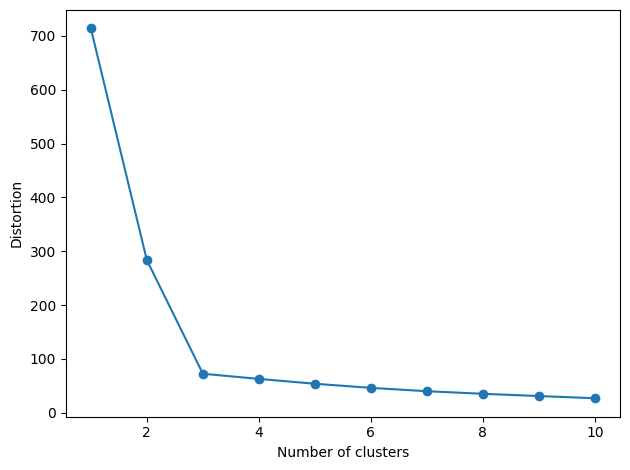

In [5]:
distortions = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, 
                init='k-means++',
                n_init=10,
                max_iter=300,
                random_state=42)
    km.fit(X)
    distortions.append(km.inertia_)

plt.plot(range(1, 11), distortions, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.tight_layout()
plt.show()

The elbow is located at k=3, so this is supporting the evidence that k=3 is indeed a good choice for this dataset.

### Quantifying the Quality of Clustering Via Silhouette Plots

The silhouette coefficient is available as silhouette_samples from scikit-learn's metric module, and optionally, silhouette_scores function can be imported for convenience. The silhouette_scores function calculates the average silhouette coefficient across all examples, which is equivalent to numpy.mean(silhouette_samples()). By executing the following code, we will now create a plot of the silhouette coefficients for a k-means clustering k=3:

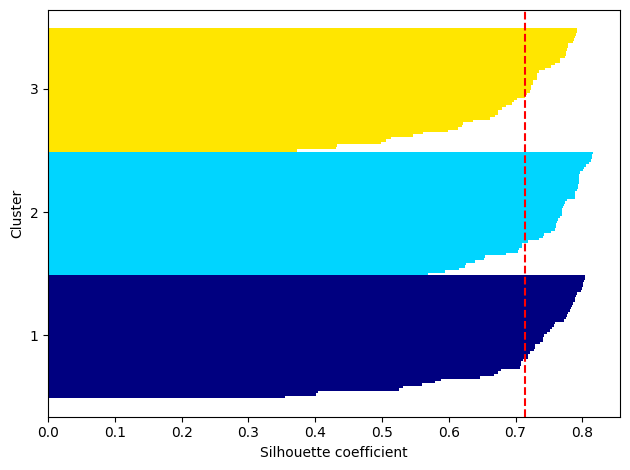

In [6]:
km = KMeans(n_clusters=3, 
            init='k-means++',
            n_init=10,
            max_iter=300,
            tol=1e-04,
            random_state=0)
y_km = km.fit_predict(X)

import numpy as np
from matplotlib import cm
from sklearn.metrics import silhouette_samples
cluster_labels = np.unique(y_km)
n_clusters = cluster_labels.shape[0]
silhouette_vals = silhouette_samples(X, y_km, metric='euclidean')
y_ax_lower, y_ax_upper = 0, 0
yticks = []
for i, c in enumerate(cluster_labels):
    c_silhouette_vals = silhouette_vals[y_km == c]
    c_silhouette_vals.sort()
    y_ax_upper += len(c_silhouette_vals)
    color = cm.jet(float(i) / n_clusters)
    plt.barh(range(y_ax_lower, y_ax_upper),
             c_silhouette_vals,
             height=1.0,
             edgecolor='none',
             color=color)
    yticks.append((y_ax_lower + y_ax_upper) / 2)
    y_ax_lower += len(c_silhouette_vals)

silhouette_avg = np.mean(silhouette_vals)
plt.axvline(silhouette_avg, color="red", linestyle="--")
plt.yticks(yticks, cluster_labels + 1)
plt.ylabel('Cluster')
plt.xlabel('Silhouette coefficient')
plt.tight_layout()
plt.show()


Through a visual inspection of the silhouette plot, we can quickly scrutinize the sizes of the different clusters and identify clusters that contain outliers.

As you can see in the preceding plot, the silhouette coefficients are not close to 0 and are approximately equally far away from the average silhouette score, which is, in this case, an indicator of good clustering. Furthermore, to summarize the goodness of our clustering, we added the average silhouette coefficient to the plot (dotted line).

To see what a silhouette plot looks like for a relatively bad clustering, let's seed the k-means algorithm with only two centroids:

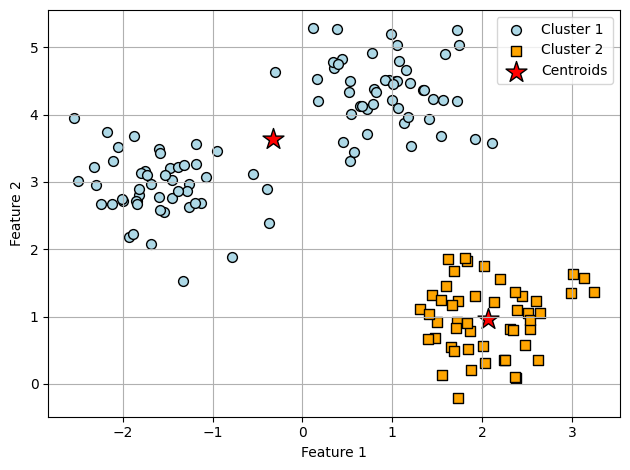

In [7]:
km = KMeans(n_clusters=2, 
            init='k-means++',
            n_init=10,
            max_iter=300,
            tol=1e-04,
            random_state=0)
y_km = km.fit_predict(X)
plt.scatter(X[y_km == 0, 0],
            X[y_km == 0, 1],
            s=50,
            c='lightblue',
            marker='o',
            edgecolor='black',
            label='Cluster 1')
plt.scatter(X[y_km == 1, 0],
            X[y_km == 1, 1],
            s=50,
            c='orange',
            marker='s',
            edgecolor='black',
            label='Cluster 2')
plt.scatter(km.cluster_centers_[:, 0],
            km.cluster_centers_[:, 1],
            s=250,
            c='red',
            marker='*',
            edgecolor='black',
            label='Centroids')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

As we can see, one of the centroids falls between two of the three spherical groupings of the input data. Although the clusterin does not completely terrible, it is suboptimal.

Please keep in mind that we typically do not have the luxury of visualizing datasets in two-dimensional scatterplots in real-world problems, since we typically work with data in higher dimensions. So, next, we will create the silhouette plot to evaluate the results:

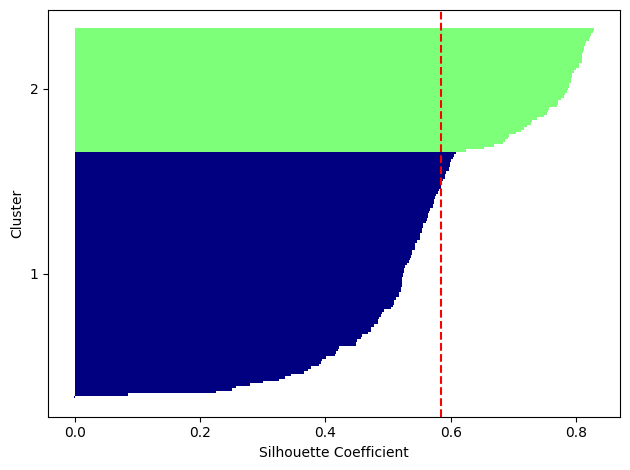

In [8]:
cluster_labels = np.unique(y_km)
n_clusters = cluster_labels.shape[0]
silhouette_vals = silhouette_samples(X, y_km, metric='euclidean')
y_ax_lower, y_ax_upper = 0, 0
yticks = []
for i, c in enumerate(cluster_labels):
    c_silhouette_vals = silhouette_vals[y_km == c]
    c_silhouette_vals.sort()
    y_ax_upper += len(c_silhouette_vals)
    color = cm.jet(float(i) / n_clusters)
    plt.barh(range(y_ax_lower, y_ax_upper),
             c_silhouette_vals,
             height=1.0,
             edgecolor='none',
             color=color)
    yticks.append((y_ax_lower + y_ax_upper) / 2.)
    y_ax_lower += len(c_silhouette_vals)
silhouette_avg = np.mean(silhouette_vals)
plt.axvline(silhouette_avg, color="red", linestyle="--")
plt.yticks(yticks, cluster_labels + 1)
plt.ylabel('Cluster')
plt.xlabel('Silhouette Coefficient')
plt.tight_layout()
plt.show()

### Grouping Clusters in a Bottom-Up Fashion

Let's generate a random data sample to work with. The rows represent different observations and the columns are the different features (X, Y, Z) of those examples:

In [9]:
import pandas as pd
import numpy as np
np.random.seed(123)
variables = ['X', 'Y', 'Z']
labels = ['ID_0', 'ID_1', 'ID_2', 'ID_3', 'ID_4']
X = np.random.random_sample([5, 3])*10
df = pd.DataFrame(X, columns=variables, index=labels)
df

,X,Y,Z
ID_0,6.964692,2.861393,2.268515
ID_1,5.513148,7.194690,4.231065
ID_2,9.807642,6.848297,4.809319
ID_3,3.921175,3.431780,7.290497
ID_4,4.385722,0.596779,3.980443


After executing the code above, we should now see this DataFrame containing the randomly generated examples.

### Performing Hierarchical Clustering on a Distance Matrix

To calculate the distance matrix as input for the hierarchical clustering algorithm, we will use the pdist function from SciPy's spatial.distance submodule:

In [10]:
from scipy.spatial.distance import pdist, squareform
row_dist = pd.DataFrame(squareform(
    pdist(df, metric='euclidean')),
    columns=labels,
    index=labels
)
row_dist

,ID_0,ID_1,ID_2,ID_3,ID_4
ID_0,0.000000,4.973534,5.516653,5.899885,3.835396
ID_1,4.973534,0.000000,4.347073,5.104311,6.698233
ID_2,5.516653,4.347073,0.000000,7.244262,8.316594
ID_3,5.899885,5.104311,7.244262,0.000000,4.382864
ID_4,3.835396,6.698233,8.316594,4.382864,0.000000


Using the preceding code, we calculated the Euclidean distance between each pair of input examples in our dataset based on the features X, Y, and Z.

We provided the condensed distance matrix - returned by pdist - as input to the squareform function to create a symmetrical matrix of the pair-wise distances, as shown above.

Next, we will apply the complete linkage agglomeration to our clusters using the linkage function from SciPy's cluster.hierarchy submodule, which returns a linkage matrix:

In [11]:
from scipy.cluster.hierarchy import linkage
row_clusters = linkage(df.values, 
                       method='complete',
                       metric='euclidean')

pd.DataFrame(row_clusters,
             columns = ['row label 1',
                        'row label 2',
                        'distance',
                        'no. of items in clust.'],
                    index=[f'cluster {(i + 1)}' for i in 
                           range(row_clusters.shape[0])])

,row label 1,row label 2,distance,no. of items in clust.
cluster 1,0.0,4.0,3.835396,2.0
cluster 2,1.0,2.0,4.347073,2.0
cluster 3,3.0,5.0,5.899885,3.0
cluster 4,6.0,7.0,8.316594,5.0


Now that we have computed the linkage matrix, we can visualize the results in the form of a dendogram:

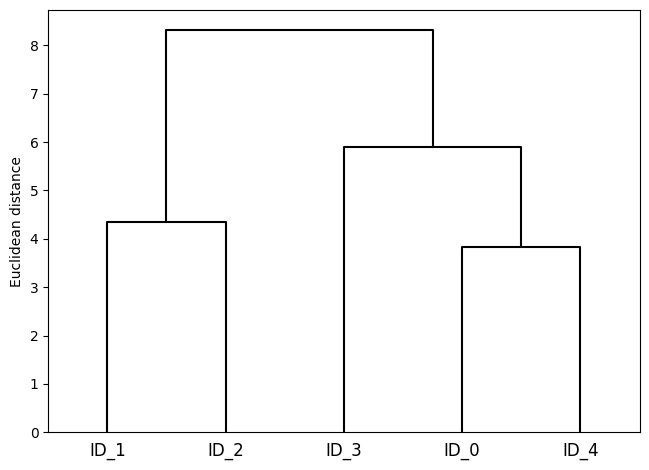

In [12]:
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import set_link_color_palette
set_link_color_palette(['black'])
row_dendr = dendrogram(row_clusters,
                       labels=labels,
                       color_threshold=np.inf)
plt.tight_layout()
plt.ylabel('Euclidean distance')
plt.show()

Such a dendrogram summarizes the different clusters that were formed during the agglomerative hierarchical clustering, for example, you can see that the examples ID_0 and ID_4, followed by ID_1 and ID_2, are the most similar ones based on the Euclidean distance metric.

### Attaching Dendrograms to a Heat Map

In practical applications, hierarchical clustering dendrograms are often used in combination with a heat map, which allows us to represent the individual values in the data array or matrix containing our training examples with a color code. In this section, we will discuss howt o attach a dendrogram to a heat map plot and order the rows in the heat map correspondingly.

However, attaching a dendrogram to a heat map can be a little tricky, so let's go through the procedure step by step:

We create a new figure object and define the x axis position, y axis position, width, and height of the dendrogram via the add_axes attribute. Furthermore, we rotate the dendrogram 90 degrees counterclockwise. The code is as follows:

In [13]:
plt.ioff()
fig = plt.figure(figsize=(8, 8), facecolor='white')
axd = fig.add_axes([0.08, 0.1, 0.2, 0.6])
row_dendr = dendrogram(row_clusters,
                       orientation='left')

Next, we reorder the data in our initial DataFrame according to the clustering labels that can be accessed from the dendrogram object, which is essentially a Python dictionary, via the leaves key. The code is as follows:

In [14]:
df_rowclust = df.iloc[row_dendr['leaves'][::-1]]

Now, we construct the heat map from the reordered DataFrame and position it next to the dendrogram:

In [15]:
axm = fig.add_axes([0.23, 0.1, 0.6, 0.6])
cax = axm.matshow(df_rowclust,
                  interpolation='nearest',
                  cmap='hot_r')

Finally, we modify the aesthetics of the dendrogram by removing the axis ticks and hiding the axis spines. Also, we add a color bar and assign the feature and data record names to the x and y axis tick labels, respectively:

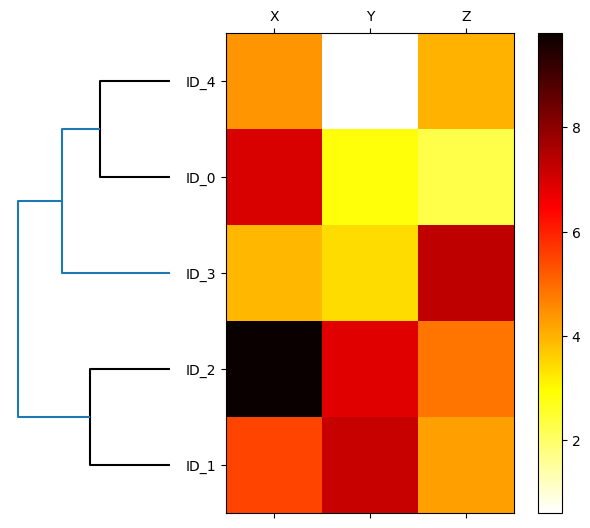

In [16]:
axd.set_xticks([])
axd.set_yticks([])
for i in axd.spines.values():
    i.set_visible(False)
fig.colorbar(cax)
axm.set_xticks(range(df_rowclust.shape[1]),
               labels=df_rowclust.columns)
axm.set_yticks(range(df_rowclust.shape[0]),
               labels=df_rowclust.index)
plt.show()
plt.ion();

As we can see, the order of rows in the heat map reflects the clustering of the examples in the dendrogram. In addition to a simple dendrogram, the color-coded values of each example and feature in the heat map provide us with a nice summary of the dataset.

### Applying Agglomerative Clustering via scikit-learn

In the previous section, we performed agglomerative hierarchical clustering using SciPy. However, there is also an AgglomerativeClustering implementation in scikit-learn, which allows us to choose the number of clusters that we want to return. This is useful if we want to prune the hierarchical cluster tree.

By setting the n_cluster parameter to 3, we will now cluster the input examples into three groups using the same complete linkage approach based on the Euclidean distance metric as before:

In [17]:
from sklearn.cluster import AgglomerativeClustering
ac = AgglomerativeClustering(n_clusters=3,
                             metric='euclidean',
                             linkage='complete')
labels = ac.fit_predict(X)
print(f'Cluster labels: {labels}')

Cluster labels: [1 0 0 2 1]


Looking at the predicted cluster labels, we can see that the first and the fifth examples (ID_0 and ID_4) were assigned to one cluster (label 1) and the examples ID_1 and ID_2 were assigned to a second cluster (label 0). The example ID_3 was put into its own cluster (label 2). Overall, the results are consistent with the results that we observed in the dendrogram. We should note, though, that ID_3 is more similar to ID_4 and ID_0 than to ID_1 and ID_2, as shown in the dendrogram figure, which is not clear in scikit-learn's clustering results. Let's now rerun the AgglomerativeClustering using n_clusters=2 in the following code snippet:

In [18]:
ac = AgglomerativeClustering(n_clusters=2,
                             metric='euclidean',
                             linkage='complete')
labels = ac.fit_predict(X)
print(f'Cluster labels: {labels}')

Cluster labels: [0 1 1 0 0]


As you can see, in this pruned clustering hierarchy, label ID_3 was assigned to the same cluster as ID_0 and ID_4, as expected.

### Locating Regions of High Density via DBSCAN

Let's create a new dataset of half-moon-shaped structures to compare the k-means clustering, hierarchical clustering, DBSCAN:

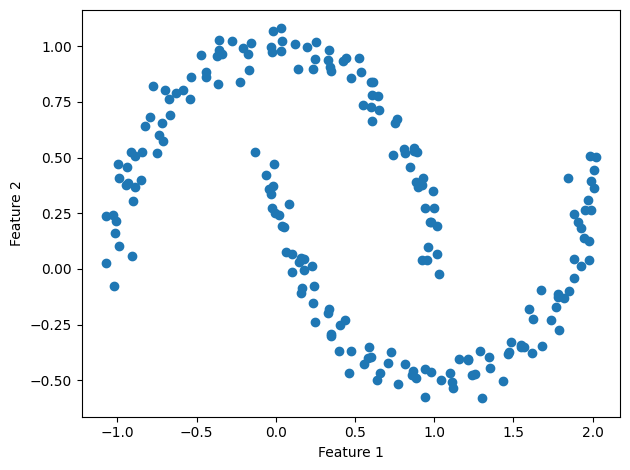

In [19]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=200,
                  noise=0.05,
                  random_state=0)
plt.scatter(X[:, 0], X[:, 1])
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.tight_layout()
plt.show()

As you can see in the resulting plot, there are two visible, half-moon shaped groups consisting of 100 examples (data points) each.

We will start by using the k-means algorithm and complete the linkage clustering to see if one of those previously discussed clustering algorithms can successfully identify the half-moon shapes as separate clusters. The code is as follows:

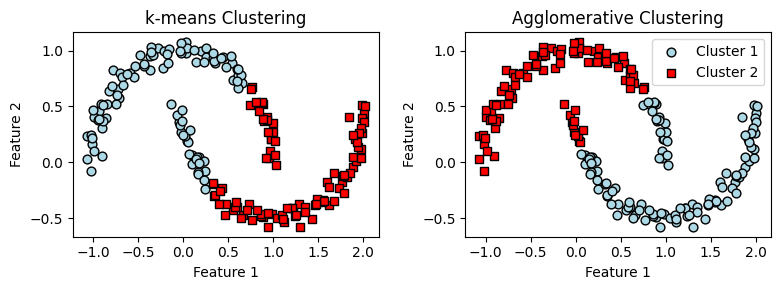

In [20]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
km = KMeans(n_clusters=2, 
            random_state=0)
y_km = km.fit_predict(X)
ax1.scatter(X[y_km == 0, 0], 
            X[y_km == 0, 1],
            c='lightblue',
            edgecolor='black',
            marker='o',
            s=40,
            label='Cluster 1')
ax1.scatter(X[y_km == 1, 0], 
            X[y_km == 1, 1],
            c='red',
            edgecolor='black',
            marker='s',
            s=40,
            label='Cluster 2')
ax1.set_title('k-means Clustering')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')

ac = AgglomerativeClustering(n_clusters=2,
                             metric='euclidean',
                             linkage='complete')
y_ac = ac.fit_predict(X)
ax2.scatter(X[y_ac == 0, 0], 
            X[y_ac == 0, 1],
            c='lightblue',
            edgecolor='black',
            marker='o',
            s=40,
            label='Cluster 1')
ax2.scatter(X[y_ac == 1, 0], 
            X[y_ac == 1, 1],
            c='red',
            edgecolor='black',
            marker='s',
            s=40,
            label='Cluster 2')
ax2.set_title('Agglomerative Clustering')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
plt.legend()
plt.tight_layout()
plt.show()

Based on the visualized clustering results, we can see that the k-means algorithm was unable to separate the two clusters, and also, the hierarchical clustering algorithms was challenged by those complex shapes.

Finally, let's try the DBSCAN algorithm on this dataset to see if it can find the two half-moon-shaped clusters using a density-based approach:

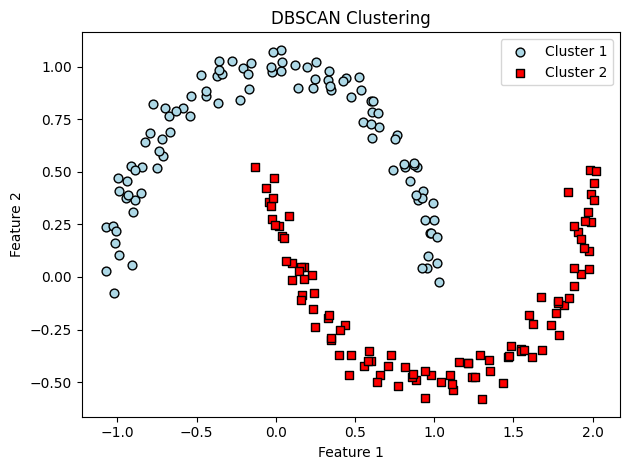

In [21]:
from sklearn.cluster import DBSCAN
db = DBSCAN(eps=0.2,
            min_samples=5,
            metric='euclidean')
y_db = db.fit_predict(X)
plt.scatter(X[y_db == 0, 0],
            X[y_db == 0, 1],
            c='lightblue',
            edgecolor='black',
            marker='o',
            s=40,
            label='Cluster 1')
plt.scatter(X[y_db == 1, 0],
            X[y_db == 1, 1],
            c='red',
            edgecolor='black',
            marker='s',
            s=40,
            label='Cluster 2')
plt.title('DBSCAN Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.tight_layout()
plt.show()

The DBSCAN algorithm can successfully detect the half-moon shapes, which highlights one of the strengths of DBSCAN - clustering data of arbitrary shapes.